# Teori for AUT-2802

## LeNet - 5

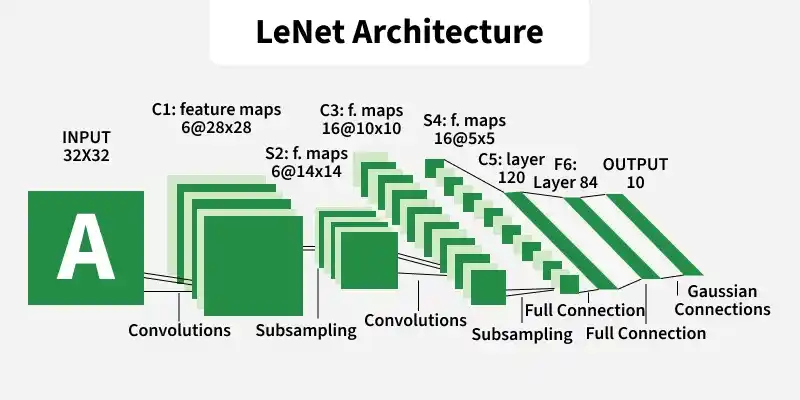

**Convolutions:** Et lite filter sveipes over bildet og lager et kart som viser hvor et bestemt mønster, som en kant, finnes.

**Subsampling:** Kartet krympes ved å slå sammen små områder til ett tall, så nettverket blir raskere og tåler at ting er flyttet litt.

**Full connection:** Hver nevron er koblet til alle verdiene i laget før, og kombinerer egenskapene som er funnet til en helhet.

**Gaussian connections:** Siste lag måler avstanden til en fast prototyp for hvert siffer, og sifferet med minst avstand blir svaret.

### Input Layer
Bildet av et håndskrevet siffer. Selve sifferet er rundt 20×20 i midten, så det er god plass rundt kantene til at filtrene får med seg alt.

### C1 Konvolusjon
Seks forskjellige filtre på 5×5 sveipes over bildet. Hvert filter lærer seg å finne sitt eget enkle mønster, som vannrette kanter, loddrette kanter eller skrå streker. Resultatet er seks kart. Bildet krymper fra 32 til 28 fordi et 5×5 filter ikke får plass helt ute i kanten.

### S2 Subsampling
Hvert av de seks kartene halveres ved at hvert 2×2 område slås sammen til ett tall. Informasjonen om hvor kantene er blir litt grovere, men det gjør nettverket mindre sårbart for at sifferet er flyttet eller skrevet litt annerledes.

### C3 Konvolusjon
Nye filtre på 5×5 sveipes over de seks kartene fra S2. Nå ser filtrene på kombinasjoner av kanter og kan finne litt større former, som hjørner og buer. En spesiell detalj i LeNet er at ikke alle de 16 kartene ser på alle de 6 kartene fra før. Hvert kart får bare et utvalg, noe som sparer beregninger og tvinger filtrene til å lære ulike ting.

### S4 Subsampling
Samme som S2

### C5 Konvolusjon
Filtrene er 5×5, akkurat like store som kartene fra S4. Filteret kan derfor bare stå på en plass, og hvert kart blir ett enkelt tall. I praksis er dette et fullt koblet lag med 120 nevroner som hver ser på hele bildet. Det heter likevel konvolusjon fordi det ville fungert som en konvolusjon om inngangsbildet var større.

### F6 Fullt koblet
Hver av de 84 nevronene er koblet til alle 120 verdiene fra C5. Her kombineres formene til noe som ligner en beskrivelse av hele sifferet. Tallet 84 er valgt fordi det tilsvarer et bilde på 7×12 piksler, som passer med neste lag.

### Output: Gaussian connections
Det finnes en fast prototyp for hvert siffer fra 0 til 9, tegnet som et lite bilde på 7×12. Hver utgang regner ut hvor langt de 84 verdiene fra F6 er fra sin prototyp. Den utgangen med minst avstand er nettverkets svar.

---
Koden under er hentet fra Lecture 2, side 37

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 6, 5)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16 * 5 * 5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, input):
    c1 = F.relu(self.conv1(input))
    s2 = F.max_pool2d(c1, (2, 2))
    c3 = F.relu(self.conv2(s2))
    s4 = F.max_pool2d(c3, 2)
    s4 = torch.flatten(s4, 1)
    f5 = F.relu(self.fc1(s4))
    f6 = F.relu(self.fc2(f5))
    output = self.fc3(f6)
  return output

net = Net()
print(net)

ModuleNotFoundError: No module named 'torch'

## Optimaliseringsalgoritmer
torch.optim inneholder ferdige optimaliseringsalgoritmer. 
Eksempler på algoritmer som er i ```torch.optim```:

### SGD (Stochastic Gradient Descent)
Dette er det enkleste alternativet. Det justerer bare litt i riktig retning med denne formelen:

$w = w - lr * gradient$

der lr (learning rate) er steglengden. "Stocastic" betyr at gradienten regnes ut fra en liten bunke bilder om gangen, ikke hele datasettet.

### SGD med momentum og Nesterov
Vanlig SGD kan bli hakkete og sikksakke frem og tilbake. Momentum er som en ball som ruller: den husker farten fra forrige steg, så den glir jevnere og raskere i riktig retning. Nesterov er en smartere variant som først "ser fremover" til der farten vil ta den, og regner gradienten der. Det gjør at den bremser litt tidligere før den skyter forbi.

### RMSProp
Gir hver vekt sin egen steglengde. Vekter som har hatt store og ustabile gradienter får mindre steg, og vekter med små gradienter får større steg.

### Adam
Kombinerer momentum og RMSProp. Den er den vanligste standardvalget fordi den som regel fungerer godt uten mye justering.

---
I kode format vil Adam se noe sånn her ut

In [ ]:
import torch.optim as optim

optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, nesterov=True)
# eller: optimizer = optim.Adam(net.parameters(), lr=0.001)

for bilder, fasit in trainloader:
    optimizer.zero_grad()           # nullstill gamle gradienter
    output = net(bilder)
    loss = criterion(output, fasit)
    loss.backward()                 # regn ut gradientene
    optimizer.step()                # oppdater vektene

In [2]:
import torch
print(torch.__version__, torch.cuda.is_available())

2.14.0+cu126 True
